In [1]:
from nba_pbp.train_models import training_loop, get_data_loaders
from nba_pbp.model.model import ExpectedPointsLSTM

In [2]:
train_loader, val_loader = get_data_loaders(dir='./games', batch_size=2, files=10, shuffle=True)
model, loss = training_loop(train_loader=train_loader, val_loader=val_loader, epochs=30, lr=1e-4)

saved 10 games
device: cuda
Epoch 01/30 | Train Loss: 8.063378 | Val Loss: 7.462094
Epoch 02/30 | Train Loss: 8.038854 | Val Loss: 7.379066
Epoch 03/30 | Train Loss: 7.912641 | Val Loss: 7.259137
Epoch 04/30 | Train Loss: 7.785425 | Val Loss: 7.119303
Epoch 05/30 | Train Loss: 7.663108 | Val Loss: 6.964445
Epoch 06/30 | Train Loss: 7.458791 | Val Loss: 6.795114
Epoch 07/30 | Train Loss: 7.288456 | Val Loss: 6.610381
Epoch 08/30 | Train Loss: 7.077430 | Val Loss: 6.409929
Epoch 09/30 | Train Loss: 6.861701 | Val Loss: 6.193862
Epoch 10/30 | Train Loss: 6.629213 | Val Loss: 5.968965
Epoch 11/30 | Train Loss: 6.354483 | Val Loss: 5.751836
Epoch 12/30 | Train Loss: 6.132433 | Val Loss: 5.577121
Epoch 13/30 | Train Loss: 5.932430 | Val Loss: 5.493428
Epoch 14/30 | Train Loss: 5.843969 | Val Loss: 5.508992
Epoch 15/30 | Train Loss: 5.819891 | Val Loss: 5.526054
Epoch 16/30 | Train Loss: 5.821055 | Val Loss: 5.471167
Epoch 17/30 | Train Loss: 5.755099 | Val Loss: 5.387666
Epoch 18/30 | Train 

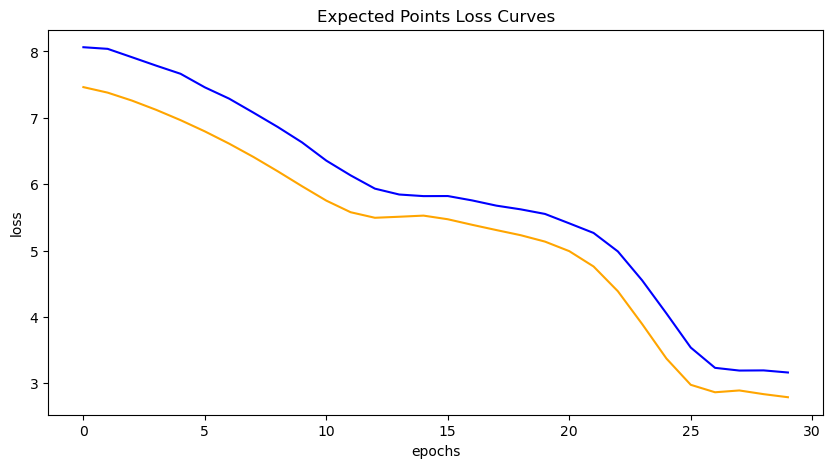

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(loss['train_loss'], label='Training Loss', color='blue')
plt.plot(loss['val_loss'], label='Validation Loss', color='orange')
plt.title('Expected Points Loss Curves')
plt.xlabel('epochs')
plt.ylabel('loss')

plt.show()

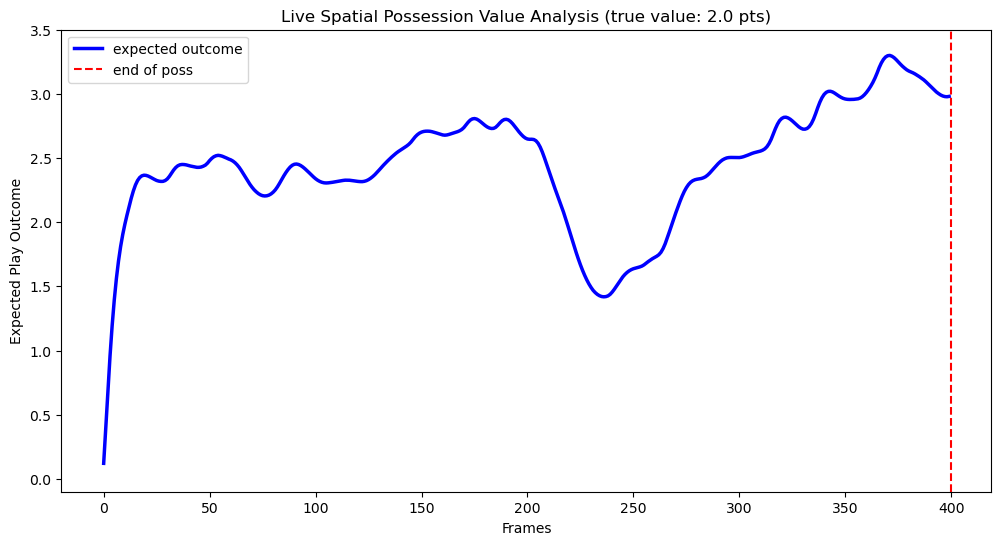

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()
found_X, found_len, found_y = None, None, None
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with torch.no_grad():
    for val_batch_X, val_batch_y, val_batch_lengths in val_loader:
        scoring_indices = torch.where(val_batch_y > 0)[0]
        if len(scoring_indices) > 0:
            target_idx = scoring_indices[0].item()
            found_X = val_batch_X[target_idx : target_idx + 1]
            found_len = val_batch_lengths[target_idx : target_idx + 1]
            found_y = val_batch_y[target_idx].item()
            break 

if found_X is not None:
    with torch.no_grad():
        raw_prediction = model(found_X.to(device), found_len.to(device))
        predictions = raw_prediction.squeeze().cpu().numpy() * 3

    plt.figure(figsize=(12, 6))
    plt.plot(predictions, label="expected outcome", color="blue", linewidth=2.5)
    plt.axvline(x=found_len.item(), color="red", linestyle="--", label="end of poss")
    plt.title(f"Live Spatial Possession Value Analysis (true value: {found_y} pts)")
    plt.xlabel("Frames")
    plt.ylabel("Expected Play Outcome")
    plt.ylim(-0.1, 3.5)
    plt.legend()
    plt.show()